# 4장 분류 - XGBoost, LightGBM, HyperOpt 정리


---


## 4.6 XGBoost (eXtra Gradient Boost)

XGBoost는 GBM 기반인데 병렬학습이 가능해서 훨씬 빠르고, 과적합 규제(regularization),  
Tree pruning, 자체 교차검증, 결측값 처리 등 GBM의 단점을 많이 보완한 알고리즘이다.

XGBoost 파이썬 패키지는 두 가지 인터페이스를 제공한다.
- **파이썬 래퍼 XGBoost**: `xgboost as xgb` 로 임포트, `xgb.train()` 사용
- **사이킷런 래퍼 XGBoost**: `XGBClassifier`, `XGBRegressor` → fit/predict 사용 (사이킷런 호환)


### 먼저 XGBoost 버전 확인부터

In [1]:
import xgboost

print(xgboost.__version__)

1.7.6


### 파이썬 래퍼 XGBoost 적용 – 위스콘신 유방암 예측

위스콘신 유방암 데이터셋을 불러와서 DataFrame으로 만들어본다.

In [2]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)
cancer_df['target'] = y_label
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


타겟 클래스 분포를 확인. 0은 악성(malignant), 1은 양성(benign).

In [3]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


학습/테스트 데이터 분리.  
원본을 8:2로 먼저 나누고, 그 학습 데이터를 다시 9:1로 나눠서  
**조기 중단(early stopping)** 에 쓸 검증 데이터까지 따로 빼놓는다.

In [4]:
# cancer_df에서 feature DataFrame과 Label Series를 추출
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 8:2로 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label,
                                                    test_size=0.2, random_state=156)

# 학습 데이터를 다시 9:1로 분리해서 검증용 데이터 확보
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


파이썬 래퍼 XGBoost는 입력 데이터로 **DMatrix**라는 자체 자료구조를 사용한다.  
넘파이/판다스를 바로 못 받기 때문에 변환을 해줘야 한다.

In [5]:
# 학습, 검증, 테스트용 DMatrix 생성
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

하이퍼파라미터 설정.  
- `max_depth`: 트리 최대 깊이 (3 정도로 작게)  
- `eta`: 학습률 (사이킷런의 learning_rate에 해당)  
- `objective`: 이진분류라 logistic  
- `eval_metric`: 평가지표 logloss

In [6]:
params = {'max_depth': 3,
          'eta': 0.05,
          'objective': 'binary:logistic',
          'eval_metric': 'logloss'
         }
num_rounds = 400

`xgb.train()`으로 학습을 수행한다.  
`evals`에 (검증세트, 이름) 튜플 리스트를 넣어주면 학습 진행 중에  
각 데이터셋의 로그로스가 계속 출력된다.  
`early_stopping_rounds=50` → 50번 연속으로 성능 향상이 없으면 조기 중단.

In [7]:
# 학습 데이터는 'train', 평가 데이터는 'eval'로 명기
eval_list = [(dtr, 'train'), (dval, 'eval')]

# 하이퍼파라미터와 조기중단 파라미터를 train()에 전달
xgb_model = xgb.train(params=params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.65016	eval-logloss:0.66183


[1]	train-logloss:0.61131	eval-logloss:0.63609


[2]	train-logloss:0.57563	eval-logloss:0.61144


[3]	train-logloss:0.54310	eval-logloss:0.59204


[4]	train-logloss:0.51323	eval-logloss:0.57329


...

[172]	train-logloss:0.01297	eval-logloss:0.26157


[173]	train-logloss:0.01285	eval-logloss:0.26253

[174]	train-logloss:0.01278	eval-logloss:0.26229


[175]	train-logloss:0.01267	eval-logloss:0.26086


[176]	train-logloss:0.01258	eval-logloss:0.26103

학습된 모델로 테스트 데이터 예측. `predict()`는 확률값을 반환하니까 0.5 기준으로 0/1 변환해야 한다.

In [8]:
pred_probs = xgb_model.predict(dtest)
print('predict() 결과값 10개 (예측 확률값)')
print(np.round(pred_probs[:10], 3))

# 0.5 기준으로 0/1 변환
preds = [1 if x > 0.5 else 0 for x in pred_probs]
print('예측값 10개:', preds[:10])

predict() 결과값 10개 (예측 확률값)


[0.845 0.008 0.68  0.081 0.975 0.999 0.998 0.998 0.996 0.001]
예측값 10개: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


평가 지표를 한 번에 출력하는 함수를 만들어둔다. 뒤에서 계속 재사용할 예정.

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [10]:
get_clf_eval(y_test, preds, pred_probs)

오차 행렬

[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9937


피처 중요도 시각화.  
`plot_importance()`는 자동으로 중요도 순으로 정렬된 막대그래프를 그려준다.  
숫자형 인덱스(f0, f1...) 형태로 나오는데, 이건 DMatrix 만들 때 컬럼명 정보가 안 들어가서 그렇다.

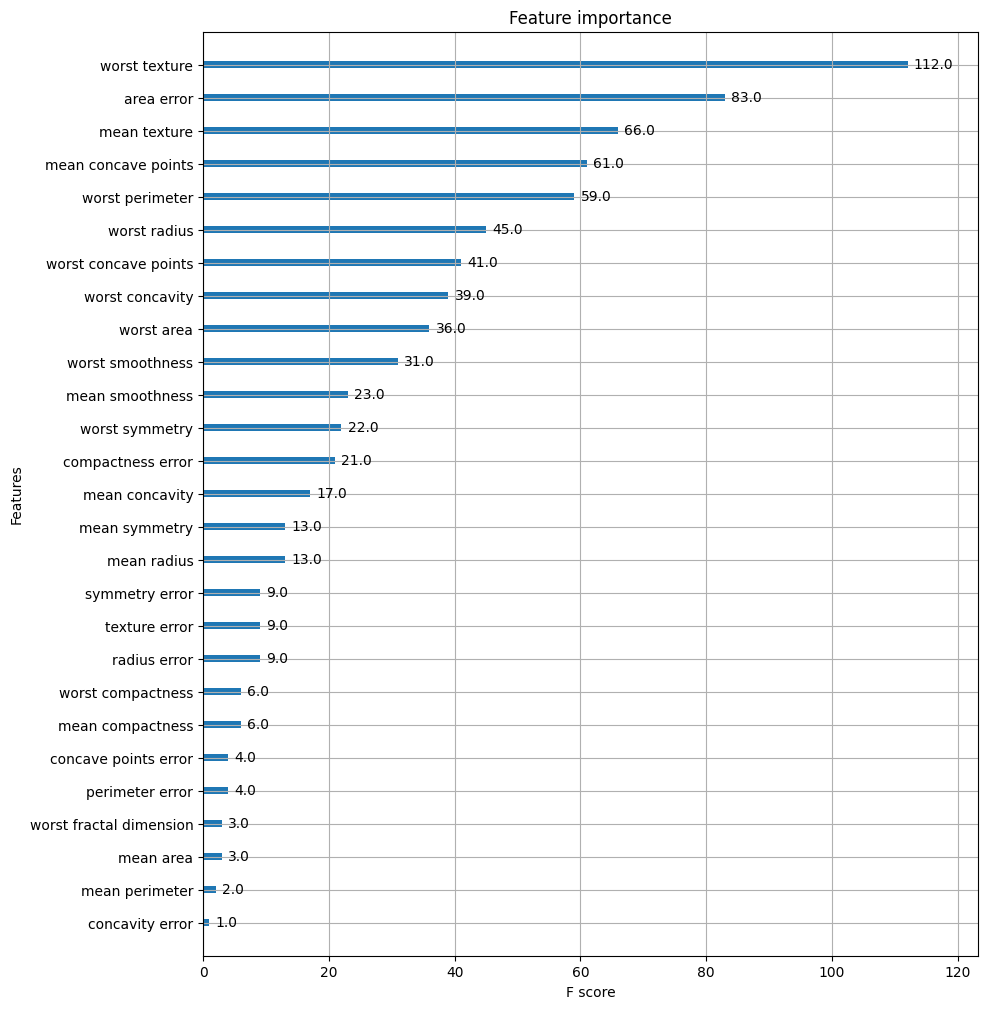

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)
plt.show()

### 사이킷런 래퍼 XGBoost의 개요 및 적용

위에서 사용한 파이썬 래퍼 XGBoost는 사이킷런과 사용법이 달라서 좀 불편하다.  
사이킷런 래퍼인 `XGBClassifier`를 쓰면 익숙한 fit/predict 인터페이스로 쓸 수 있다.  
하이퍼파라미터도 사이킷런 스타일 명칭으로 바뀐다: `eta` → `learning_rate`, `num_boost_round` → `n_estimators` 등.

In [12]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)
xgb_wrapper.fit(X_train, y_train)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

In [13]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차 행렬
[[35  2]
 [ 1 76]]
정확도: 0.9737, 정밀도: 0.9744, 재현율: 0.9870,    F1: 0.9806, AUC:0.9951


사이킷런 래퍼에서도 조기 중단을 적용해본다. `fit()`에 `early_stopping_rounds`, `eval_metric`, `eval_set`을 넘겨주면 된다.

In [14]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)
evals = [(X_test, y_test)]
xgb_wrapper.fit(X_train, y_train, early_stopping_rounds=100, eval_metric="logloss",
                eval_set=evals, verbose=True)

ws100_preds = xgb_wrapper.predict(X_test)
ws100_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.61352


[1]	validation_0-logloss:0.54784


[2]	validation_0-logloss:0.49425


[3]	validation_0-logloss:0.44799


[4]	validation_0-logloss:0.40911


...

[307]	validation_0-logloss:0.08600


[308]	validation_0-logloss:0.08600


[309]	validation_0-logloss:0.08588


[310]	validation_0-logloss:0.08592


[311]	validation_0-logloss:0.08595


In [15]:
get_clf_eval(y_test, ws100_preds, ws100_pred_proba)

오차 행렬

[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870,    F1: 0.9744, AUC:0.9954


`early_stopping_rounds`를 너무 작게(10) 잡으면 어떻게 되는지도 확인.  
조기 중단이 너무 일찍 발동돼서 모델이 충분히 학습되지 못해 성능이 떨어질 수 있다.

In [16]:
# early_stopping_rounds를 10으로 설정하고 재학습
xgb_wrapper.fit(X_train, y_train, early_stopping_rounds=10,
                eval_metric="logloss", eval_set=evals, verbose=True)

ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.61352


[1]	validation_0-logloss:0.54784


[2]	validation_0-logloss:0.49425


[3]	validation_0-logloss:0.44799

[4]	validation_0-logloss:0.40911


...

[58]	validation_0-logloss:0.09199


[59]	validation_0-logloss:0.09195


[60]	validation_0-logloss:0.09194


[61]	validation_0-logloss:0.09146


오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9947


사이킷런 래퍼 모델도 `plot_importance()`에 그대로 넣을 수 있다. 이번엔 컬럼명이 잘 표시된다.

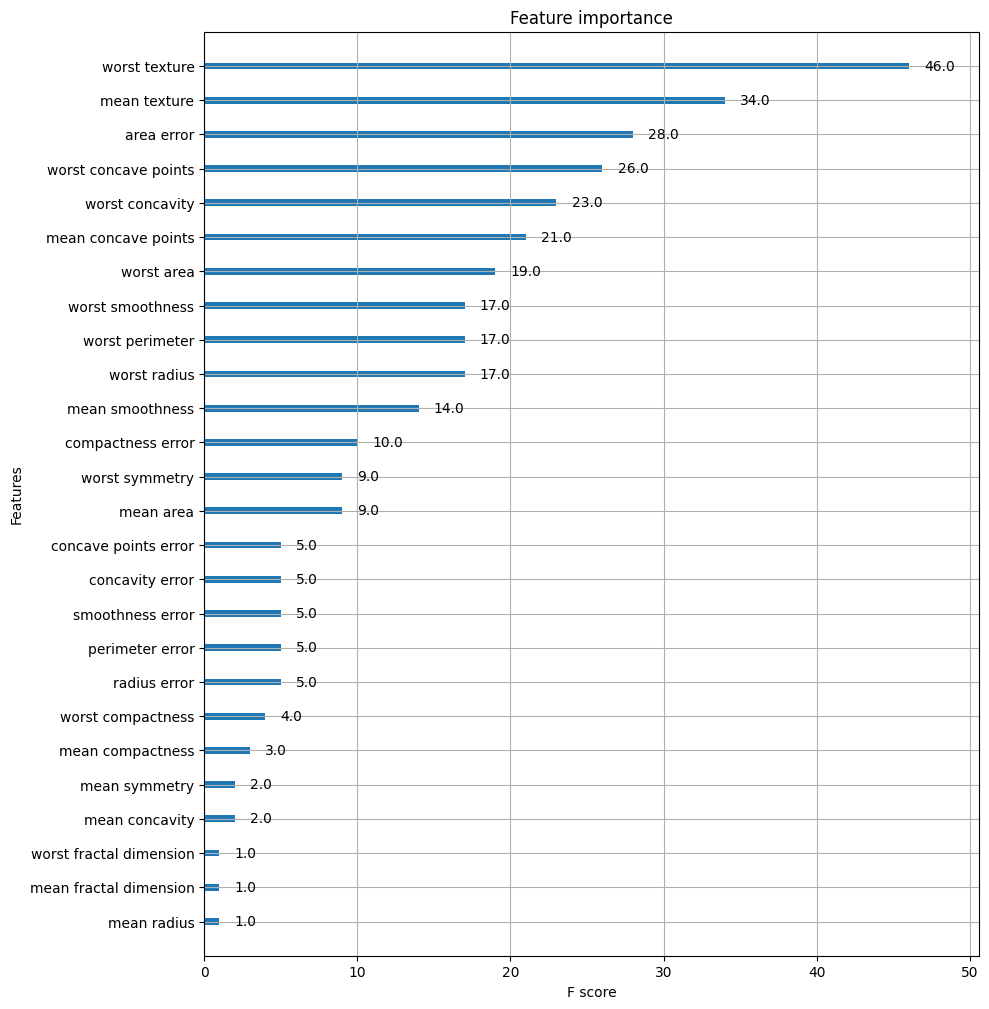

In [17]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_wrapper, ax=ax)
plt.show()

---

## 4.7 LightGBM

LightGBM은 XGBoost보다 더 빠르고, 메모리도 적게 쓰면서 비슷한 성능을 낸다.  
대신 단점은 **데이터가 작을 때(보통 10,000건 이하) 과적합 위험이 크다**는 점.

XGBoost와 가장 큰 차이는 트리 분할 방식:
- XGBoost: **균형 트리 분할(Level-wise)** → 균형은 잡히는데 시간이 오래 걸림
- LightGBM: **리프 중심 트리 분할(Leaf-wise)** → 비대칭이지만 예측 오류 손실을 더 줄임

API는 XGBoost와 거의 비슷해서 금방 익숙해진다.

### LightGBM 버전 확인

In [18]:
import lightgbm

print(lightgbm.__version__)

3.3.5


### LightGBM 적용 – 위스콘신 유방암 예측

XGBoost 때와 동일하게 데이터를 준비하고, `LGBMClassifier`로 학습한다.  
사이킷런 래퍼라 fit/predict 인터페이스를 그대로 쓸 수 있다.

In [19]:
# LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 8:2로 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 학습 데이터에서 다시 9:1로 검증 데이터 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

# XGBoost와 동일하게 n_estimators=400
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# LightGBM도 조기 중단 가능
evals = [(X_tr, y_tr), (X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr, early_stopping_rounds=50, eval_metric="logloss",
                 eval_set=evals, verbose=True)
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	valid_1's binary_logloss: 0.502637
[8]	training's binary_logloss: 0.425055	valid_1's binary_logloss: 0.488311
[9]	training's binary_logloss: 0.405125	valid_1's binary_logloss: 0.474664
[10]	training's binary_logloss: 0.386526	valid_1's binary_logloss: 0.461267
[11]	training's binary_logloss: 0.367027	valid_1's binary_logloss: 0.444274
[12]	training's binary_logloss: 0.350713	valid_1's binary_logloss: 0.432755
[13]	training's binary_logloss: 0.334601	valid_1's binary_logloss: 0.421371
[14]	training's binary

위에서 만들어둔 `get_clf_eval()` 함수로 평가. (혹시나 해서 다시 정의)

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [21]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9877


LightGBM도 자체 `plot_importance()` 함수가 있다.

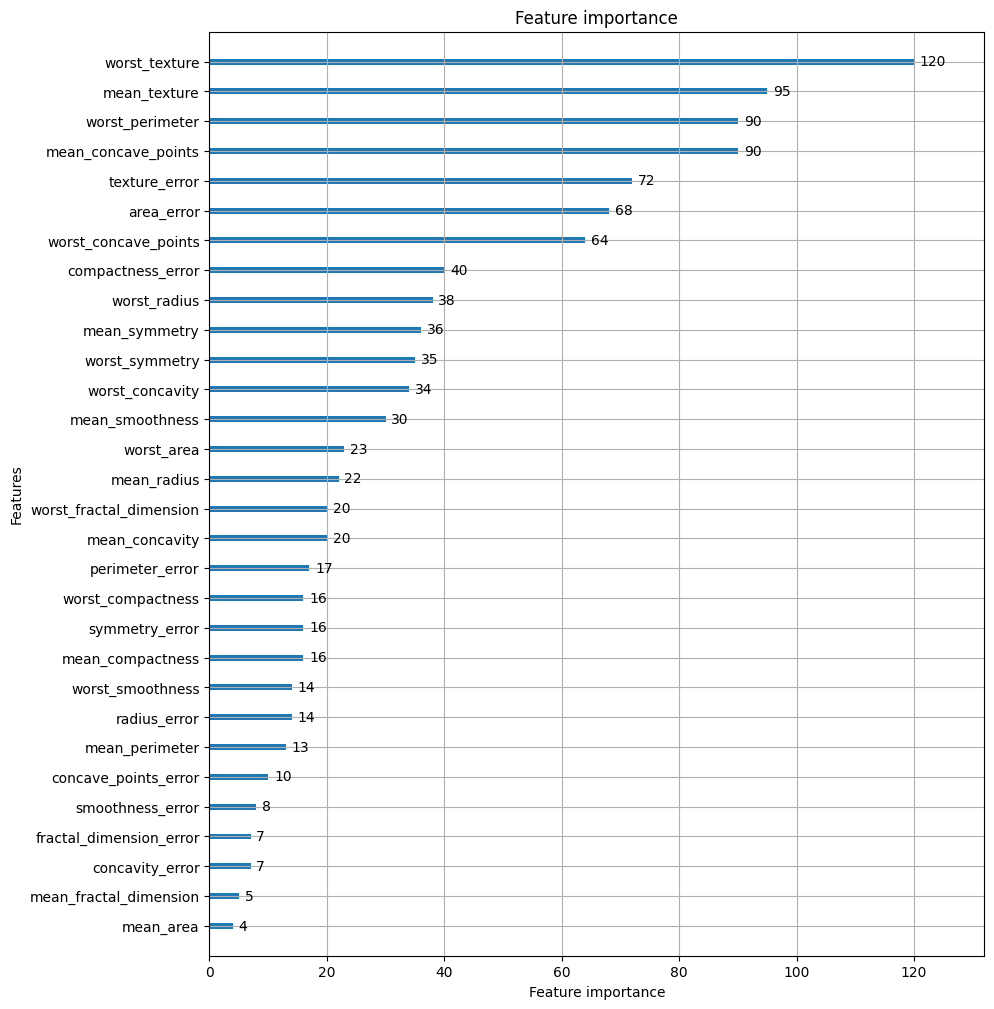

In [22]:
# plot_importance()로 피처 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)
plt.show()

---

## 4.8 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼파라미터 튜닝

GridSearchCV로 하이퍼파라미터 튜닝을 하면 경우의 수가 많을수록 시간이 너무 오래 걸린다.  
**베이지안 최적화(Bayesian Optimization)** 는 이전 시도 결과를 바탕으로 다음에 시도할 값을  
"똑똑하게" 골라가는 방식이라서 GridSearch보다 훨씬 적은 횟수로 좋은 값을 찾을 수 있다.

대표적인 파이썬 패키지가 **HyperOpt**.

핵심 개념 정리:
1. **검색 공간(Search Space)**: 어떤 값들을 탐색할지 정의 (`hp.quniform`, `hp.uniform` 등)
2. **목적 함수(Objective Function)**: 최소화하고 싶은 값을 반환하는 함수
3. **`fmin()`**: 목적 함수를 최소화하는 입력값을 찾아주는 함수
4. **`Trials`**: 시도 기록을 저장하는 객체

### HyperOpt 버전 확인

In [23]:
import hyperopt

print(hyperopt.__version__)

0.2.7


### 1) 간단한 예제로 HyperOpt 동작 이해하기

검색공간 정의. `hp.quniform(label, low, high, q)` → low~high 사이를 q 간격으로 균등 추출.

In [24]:
from hyperopt import hp

# -10 ~ 10까지 1간격을 가지는 입력 변수 x와 -15 ~ 15까지 1간격으로 입력 변수 y 설정
search_space = {'x': hp.quniform('x', -10, 10, 1), 'y': hp.quniform('y', -15, 15, 1)}

목적 함수 정의. `x**2 - 20*y` 의 최솟값을 찾는 것이 목표.  
x=0, y=15 일 때 최솟값 -300이 나오겠지.

In [25]:
from hyperopt import STATUS_OK

# 목적 함수: 변숫값 딕셔너리를 받아서 특정 값을 반환
def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2 - 20*y
    
    return retval

`fmin()`으로 최솟값을 만드는 입력값을 찾는다.  
`max_evals=5`로 일단 5번만 시도해보기.

In [26]:
from hyperopt import fmin, tpe, Trials
import numpy as np

# 입력 결과값을 저장할 Trials 객체
trial_val = Trials()

# 5번의 시도로 최적 입력값 찾기
best_01 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_01)


  0%|          | 0/5 [00:00<?, ?trial/s, best loss=?]


100%|██████████| 5/5 [00:00<00:00, 908.76trial/s, best loss: -224.0]


best: {'x': np.float64(-4.0), 'y': np.float64(12.0)}


5번은 너무 적다. `max_evals`를 20으로 늘려서 다시.

In [27]:
trial_val = Trials()

# max_evals를 20회로 늘려서 재테스트
best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=20,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_02)


  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]


100%|██████████| 20/20 [00:00<00:00, 1360.70trial/s, best loss: -296.0]


best: {'x': np.float64(2.0), 'y': np.float64(15.0)}


Trials 객체의 속성으로 시도 기록을 확인할 수 있다.
- `results`: 각 시도의 반환값 ({'loss': 값, 'status': 상태})
- `vals`: 각 시도의 입력값

In [28]:
# Trials 객체의 results 속성에 시도별 반환값이 저장됨
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [29]:
# vals 속성에 입력 변수별 시도된 값 리스트가 저장됨
print(trial_val.vals)

{'x': [np.float64(-6.0), np.float64(-4.0), np.float64(4.0), np.float64(-4.0), np.float64(9.0), np.float64(2.0), np.float64(10.0), np.float64(-9.0), np.float64(-8.0), np.float64(-0.0), np.float64(-0.0), np.float64(1.0), np.float64(9.0), np.float64(6.0), np.float64(9.0), np.float64(2.0), np.float64(-2.0), np.float64(-4.0), np.float64(7.0), np.float64(-0.0)], 'y': [np.float64(5.0), np.float64(10.0), np.float64(-2.0), np.float64(12.0), np.float64(1.0), np.float64(15.0), np.float64(7.0), np.float64(-10.0), np.float64(0.0), np.float64(-5.0), np.float64(-3.0), np.float64(2.0), np.float64(4.0), np.float64(10.0), np.float64(3.0), np.float64(3.0), np.float64(-14.0), np.float64(-8.0), np.float64(11.0), np.float64(-0.0)]}


이것들을 합쳐서 DataFrame으로 보면 어떤 (x,y) 조합에서 어떤 결과가 나왔는지 한눈에 보인다.

In [30]:
import pandas as pd

# results에서 loss 키값들만 추출
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

# DataFrame으로 생성
result_df = pd.DataFrame({'x': trial_val.vals['x'], 'y': trial_val.vals['y'], 'losses': losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


### 2) HyperOpt를 이용한 XGBoost 하이퍼파라미터 최적화

이제 진짜 ML 모델에 HyperOpt를 적용해보자. 위스콘신 유방암 데이터에 XGBoost를 쓰면서  
4개의 하이퍼파라미터를 동시에 튜닝한다.

In [31]:
# 데이터 준비 (위에서 이미 했지만 셀 독립성을 위해 다시)
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

In [32]:
# 8:2 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 학습 데이터에서 다시 9:1로 검증 데이터 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

XGBoost용 검색 공간 정의.  
- `max_depth`: 5~20, 정수 간격  
- `min_child_weight`: 1~2, 정수 간격  
- `learning_rate`: 0.01~0.2, 실수 (uniform)  
- `colsample_bytree`: 0.5~1, 실수

In [33]:
from hyperopt import hp

# max_depth 5~20, min_child_weight 1~2 (정수)
# colsample_bytree 0.5~1, learning_rate 0.01~0.2 (실수)
xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
                   }

목적 함수 정의. 주의할 점 두 가지:
1. `hp.quniform`이 반환하는 값은 실수형이라서 `max_depth`, `min_child_weight`는 `int()` 변환 필요
2. 정확도는 높을수록 좋은데 `fmin()`은 **최솟값**을 찾으니까 `-1`을 곱해서 반환

In [34]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

def objective_func(search_space):
    # 시간 절약을 위해 n_estimators는 100으로
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            learning_rate=search_space['learning_rate'],
                            colsample_bytree=search_space['colsample_bytree'],
                            eval_metric='logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)
    
    # cv=3 결과를 평균하고 -1 곱해서 반환 (정확도 높을수록 작은 값)
    return {'loss': -1 * np.mean(accuracy), 'status': STATUS_OK}

50회 시도로 최적 하이퍼파라미터 탐색.

In [35]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50,  # 최대 반복 횟수
            trials=trial_val, rstate=np.random.default_rng(seed=9))
print('best:', best)


  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]


  2%|▏         | 1/50 [00:00<00:09,  5.09trial/s, best loss: -0.9407168583710934]


  4%|▍         | 2/50 [00:00<00:08,  5.85trial/s, best loss: -0.9538747531079355]


  6%|▌         | 3/50 [00:00<00:07,  6.11trial/s, best loss: -0.9604682235389799]


  8%|▊         | 4/50 [00:00<00:07,  6.06trial/s, best loss: -0.9604682235389799]

...


 96%|█████████▌| 48/50 [00:07<00:00,  6.08trial/s, best loss: -0.9648396653886372]


 98%|█████████▊| 49/50 [00:08<00:00,  6.04trial/s, best loss: -0.9648396653886372]


100%|██████████| 50/50 [00:08<00:00,  6.43trial/s, best loss: -0.9648396653886372]


100%|██████████| 50/50 [00:08<00:00,  6.15trial/s, best loss: -0.9648396653886372]


best: {'colsample_bytree': np.float64(0.6367020408228946), 'learning_rate': np.float64(0.17542594661299368), 'max_depth': np.float64(17.0), 'min_child_weight': np.float64(2.0)}


In [36]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.6367, learning_rate:0.17543, max_depth:17, min_child_weight:2


`get_clf_eval()` 함수 다시 정의 (셀 독립성 위해).

In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

찾은 최적 하이퍼파라미터로 최종 모델 학습.  
이번엔 `n_estimators=400` 으로 크게 잡고 조기 중단까지 적용해서 끝까지 학습.

In [38]:
xgb_wrapper = XGBClassifier(n_estimators=400,
                            learning_rate=round(best['learning_rate'], 5),
                            max_depth=int(best['max_depth']),
                            min_child_weight=int(best['min_child_weight']),
                            colsample_bytree=round(best['colsample_bytree'], 5)
                           )

evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds=50, eval_metric='logloss',
                eval_set=evals, verbose=True)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)

[0]	validation_0-logloss:0.55232	validation_1-logloss:0.59166


[1]	validation_0-logloss:0.45267	validation_1-logloss:0.53027


[2]	validation_0-logloss:0.37707	validation_1-logloss:0.47056


[3]	validation_0-logloss:0.31784	validation_1-logloss:0.42540


[4]	validation_0-logloss:0.27052	validation_1-logloss:0.38484


...

[271]	validation_0-logloss:0.01205	validation_1-logloss:0.22343


[272]	validation_0-logloss:0.01205	validation_1-logloss:0.22343


[273]	validation_0-logloss:0.01205	validation_1-logloss:0.22343


오차 행렬


[[33  4]
 [ 2 75]]
정확도: 0.9474, 정밀도: 0.9494, 재현율: 0.9740,    F1: 0.9615, AUC:0.9937


---

## 정리

| 항목 | XGBoost | LightGBM |
|------|---------|----------|
| 트리 분할 | 균형 트리(Level-wise) | 리프 중심(Leaf-wise) |
| 속도 | 빠름 | 더 빠름 |
| 메모리 | 보통 | 더 적음 |
| 데이터 크기 권장 | 제약 적음 | 작은 데이터(<10000)는 과적합 주의 |

**HyperOpt** 사용 흐름:
1. `search_space` 정의 (hp.quniform / hp.uniform 등)
2. `objective_func` 정의 → 최소화할 loss 반환 (정확도면 -1 곱하기)
3. `Trials()` 생성
4. `fmin()` 호출 → 최적 하이퍼파라미터 dict 반환
5. 그 값으로 최종 모델 학습

GridSearchCV 대비 훨씬 적은 횟수로 좋은 결과를 얻을 수 있어서  
하이퍼파라미터 개수가 많을 때 진짜 유용할 것 같다.
